\# Final Project Kelompok 3 (Spirit Team) — BERT LoRA, R-LoRA, dan Full Fine-Tuning

## Versi Colab

1. **SST-2 style** - Sentiment Analysis  
2. **AG News style** - News Classification  
3. **SNLI style** - Natural Language Inference  

> **demo pipeline ringan**. Untuk eksperimen final skala besar, dataset asli dapat diganti kembali dengan SST-2, AG News, dan SNLI dari HuggingFace setelah environment stabil.


## 1. Install Library

Hal kecil diawal adalah : Cell ini menginstal versi library yang relatif stabil untuk BERT + PEFT/LoRA di Colab.  


In [1]:
# Penjelasan profesional: Cell ini menjalankan tahap penting dari pipeline.
# Perhatikan setiap langkah agar bisa dijelaskan saat presentasi.
!pip -q install "transformers==4.41.2" "peft==0.11.1" "accelerate==0.31.0" scikit-learn pandas matplotlib

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.8/43.8 kB 1.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 38.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 251.6/251.6 kB 12.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 309.4/309.4 kB 7.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 17.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.6/3.6 MB 36.4 MB/s eta 0:00:00


## 2. Import Library

Di sini kita memakai:
- `transformers` untuk BERT dan tokenizer.
- `peft` untuk LoRA.
- `torch` untuk training manual.
- `sklearn` untuk accuracy.
- `pandas` dan `matplotlib` untuk tabel dan grafik hasil.


In [2]:
# Cell ini menjalankan tahap penting dari pipeline.
import os
import random
import gc
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt

from torch.utils.data import Dataset, DataLoader
from transformers import AutoTokenizer, AutoModelForSequenceClassification
from peft import LoraConfig, get_peft_model
from sklearn.metrics import accuracy_score

print("Torch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))


Torch version: 2.11.0+cpu
CUDA available: False


## 3. Konfigurasi Eksperimen

Agar ringan, notebook ini memakai:
- epoch = 1
- batch size = 8
- max length = 64
- jumlah data kecil

Hyperparameter utama tetap mengikuti rancangan tugas:
- learning rate = 2e-5
- dropout = 0.2


In [3]:

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

MODEL_NAME = "bert-base-uncased"

LR = 2e-5
DROPOUT = 0.2
BATCH_SIZE = 8
EPOCHS = 1
MAX_LEN = 64

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

METHODS = ["lora", "r-lora", "full-ft"]

print("Device:", DEVICE)


Device: cpu


## 4. Dataset Demo Lokal

Supaya benar-benar bisa jalan tanpa error dataset, kita membuat mini dataset lokal.

Struktur task:
- **SST-2 style**: 2 label → negative/positive
- **AG News style**: 4 label → world/sports/business/sci-tech
- **SNLI style**: 3 label → entailment/neutral/contradiction

Dataset ini hanya untuk demo pipeline. Karena ukurannya kecil, hasil akurasi tidak boleh dianggap sebagai hasil ilmiah final.


In [4]:
# SST-2 style: label 0 = negative, label 1 = positive
sst2_data = [
    ("this movie was fantastic and very enjoyable", 1),
    ("the film was boring and too long", 0),
    ("i loved the acting and the story", 1),
    ("the plot was weak and disappointing", 0),
    ("a wonderful and emotional performance", 1),
    ("this was a terrible movie", 0),
    ("the characters were interesting and funny", 1),
    ("i do not recommend this film", 0),
    ("a smart and beautiful story", 1),
    ("the movie felt slow and dull", 0),
    ("excellent direction and great music", 1),
    ("bad writing and poor acting", 0),
    ("the experience was pleasant", 1),
    ("it was not worth watching", 0),
    ("the ending was satisfying", 1),
    ("the film failed to impress me", 0),
]

# AG News style: 0=World, 1=Sports, 2=Business, 3=Sci/Tech
agnews_data = [
    ("the president met foreign leaders to discuss peace", 0),
    ("the government announced a new international policy", 0),
    ("diplomats gathered for a climate agreement", 0),
    ("the election result changed the political landscape", 0),
    ("the football team won the championship", 1),
    ("the player scored three goals in the final match", 1),
    ("the basketball coach praised the team's defense", 1),
    ("the tennis tournament attracted many fans", 1),
    ("the stock market rose after strong earnings", 2),
    ("the company reported higher quarterly revenue", 2),
    ("investors reacted to the central bank decision", 2),
    ("the startup raised funding for expansion", 2),
    ("scientists introduced a new artificial intelligence system", 3),
    ("the software update improved device security", 3),
    ("researchers developed faster computer chips", 3),
    ("a new satellite was launched into orbit", 3),
]

# SNLI style: 0=entailment, 1=neutral, 2=contradiction
snli_data = [
    ("a man is playing guitar on stage", "a person is performing music", 0),
    ("a woman is reading a book", "a woman is cooking dinner", 2),
    ("children are playing in the park", "some kids are outside", 0),
    ("a dog is running through grass", "an animal is sleeping indoors", 2),
    ("people are sitting in a restaurant", "people are eating food", 1),
    ("a boy is riding a bicycle", "a child is using a bike", 0),
    ("a teacher writes on the board", "a teacher is swimming", 2),
    ("a group is waiting at the station", "people are traveling soon", 1),
    ("a chef is cutting vegetables", "someone is preparing food", 0),
    ("a car is parked near a house", "the car is flying in the sky", 2),
    ("a student is typing on a laptop", "a student is doing schoolwork", 1),
    ("a runner crosses the finish line", "an athlete finishes a race", 0),
    ("a baby is sleeping in a crib", "a baby is awake and crying", 2),
    ("two friends are talking outside", "two people are communicating", 0),
    ("a person is holding an umbrella", "it may be raining", 1),
    ("a cat is sitting on a sofa", "an animal is on furniture", 0),
]


## 5. Dataset Class dan Tokenisasi

Cell ini mengubah teks menjadi input BERT:
- `input_ids`
- `attention_mask`
- `labels`

Untuk SNLI, input berupa pasangan kalimat: `premise` dan `hypothesis`.


In [5]:
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

class SingleSentenceDataset(Dataset):
    def __init__(self, data, tokenizer, max_len=64):
        texts = [x[0] for x in data]
        labels = [x[1] for x in data]
        enc = tokenizer(
            texts,
            truncation=True,
            padding=True,
            max_length=max_len,
            return_tensors="pt"
        )
        self.input_ids = enc["input_ids"]
        self.attention_mask = enc["attention_mask"]
        self.labels = torch.tensor(labels, dtype=torch.long)

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        return {
            "input_ids": self.input_ids[idx],
            "attention_mask": self.attention_mask[idx],
            "labels": self.labels[idx]
        }

class PairSentenceDataset(Dataset):
    def __init__(self, data, tokenizer, max_len=64):
        premise = [x[0] for x in data]
        hypothesis = [x[1] for x in data]
        labels = [x[2] for x in data]
        enc = tokenizer(
            premise,
            hypothesis,
            truncation=True,
            padding=True,
            max_length=max_len,
            return_tensors="pt"
        )
        self.input_ids = enc["input_ids"]
        self.attention_mask = enc["attention_mask"]
        self.labels = torch.tensor(labels, dtype=torch.long)

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        return {
            "input_ids": self.input_ids[idx],
            "attention_mask": self.attention_mask[idx],
            "labels": self.labels[idx]
        }

def split_data(data, train_ratio=0.75):
    data = data.copy()
    random.shuffle(data)
    split_idx = int(len(data) * train_ratio)
    return data[:split_idx], data[split_idx:]

sst2_train, sst2_eval = split_data(sst2_data)
ag_train, ag_eval = split_data(agnews_data)
snli_train, snli_eval = split_data(snli_data)

datasets = {
    "SST-2": {
        "train": SingleSentenceDataset(sst2_train, tokenizer, MAX_LEN),
        "eval": SingleSentenceDataset(sst2_eval, tokenizer, MAX_LEN),
        "num_labels": 2
    },
    "AG News": {
        "train": SingleSentenceDataset(ag_train, tokenizer, MAX_LEN),
        "eval": SingleSentenceDataset(ag_eval, tokenizer, MAX_LEN),
        "num_labels": 4
    },
    "SNLI": {
        "train": PairSentenceDataset(snli_train, tokenizer, MAX_LEN),
        "eval": PairSentenceDataset(snli_eval, tokenizer, MAX_LEN),
        "num_labels": 3
    }
}

for task, cfg in datasets.items():
    print(task, "train:", len(cfg["train"]), "eval:", len(cfg["eval"]), "labels:", cfg["num_labels"])


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

/usr/local/lib/python3.12/dist-packages/huggingface_hub/file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

SST-2 train: 12 eval: 4 labels: 2
AG News train: 12 eval: 4 labels: 4
SNLI train: 12 eval: 4 labels: 3


## 6. Membangun Model

Tiga metode yang dibandingkan:

### 1. Full Fine-Tuning
Semua parameter BERT dilatih.

### 2. LoRA
Base model BERT dibekukan, lalu adapter kecil ditambahkan pada layer attention (`query` dan `value`).

### 3. R-LoRA inspired
Mirip LoRA, tetapi bobot LoRA tertentu diberi inisialisasi random kecil. Ini mengikuti ide utama paper R-LoRA, yaitu membuat adapter tidak belajar dari titik awal yang terlalu simetris.


In [6]:
def count_parameters(model):
    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    total = sum(p.numel() for p in model.parameters())
    pct = 100 * trainable / total
    return trainable, total, pct

def build_model(method, num_labels):
    model = AutoModelForSequenceClassification.from_pretrained(
        MODEL_NAME,
        num_labels=num_labels,
        hidden_dropout_prob=DROPOUT,
        attention_probs_dropout_prob=DROPOUT
    )

    if method == "full-ft":
        return model

    if method in ["lora", "r-lora"]:
        config = LoraConfig(
            r=8,
            lora_alpha=32,
            target_modules=["query", "value"],
            lora_dropout=DROPOUT,
            bias="none",
            task_type="SEQ_CLS",
            modules_to_save=["classifier"]
        )
        model = get_peft_model(model, config)

        if method == "r-lora":
            for name, param in model.named_parameters():
                if "lora_B" in name:
                    torch.nn.init.normal_(param, mean=0.0, std=0.02)

        return model

    raise ValueError("Method harus: lora, r-lora, atau full-ft")

for method in METHODS:
    test_model = build_model(method, num_labels=2)
    tr, total, pct = count_parameters(test_model)
    print(f"{method:8s} | trainable={tr:,} | total={total:,} | trainable%={pct:.4f}")
    del test_model
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()


model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


lora     | trainable=296,450 | total=109,780,228 | trainable%=0.2700


Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


r-lora   | trainable=296,450 | total=109,780,228 | trainable%=0.2700


Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


full-ft  | trainable=109,483,778 | total=109,483,778 | trainable%=100.0000


## 7. Training dan Evaluasi Manual

Notebook ini tidak memakai `Trainer` agar menghindari error versi `transformers`.  
Training dibuat manual dengan PyTorch supaya lebih stabil di Colab.

Alurnya:
1. Model menerima batch data.
2. Model menghasilkan loss.
3. Loss dihitung mundur dengan `backward()`.
4. Optimizer memperbarui parameter.
5. Evaluasi dilakukan dengan accuracy.


In [7]:

def train_one_epoch(model, dataloader, optimizer):
    model.train()
    total_loss = 0

    for batch in dataloader:
        batch = {k: v.to(DEVICE) for k, v in batch.items()}

        optimizer.zero_grad()
        outputs = model(**batch)
        loss = outputs.loss
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    return total_loss / max(len(dataloader), 1)

def evaluate(model, dataloader):
    model.eval()
    preds_all = []
    labels_all = []
    total_loss = 0

    with torch.no_grad():
        for batch in dataloader:
            labels = batch["labels"].numpy()
            batch = {k: v.to(DEVICE) for k, v in batch.items()}

            outputs = model(**batch)
            logits = outputs.logits
            preds = torch.argmax(logits, dim=-1).cpu().numpy()

            preds_all.extend(preds)
            labels_all.extend(labels)
            total_loss += outputs.loss.item()

    acc = accuracy_score(labels_all, preds_all)
    avg_loss = total_loss / max(len(dataloader), 1)

    return avg_loss, acc


## 8. Menjalankan Eksperimen

Cell ini menjalankan 9 eksperimen:
- 3 task × 3 metode

Karena dataset demo sangat kecil, jadi pasti bisa selesai

In [8]:
results = []

for task_name, cfg in datasets.items():
    train_loader = DataLoader(cfg["train"], batch_size=BATCH_SIZE, shuffle=True)
    eval_loader = DataLoader(cfg["eval"], batch_size=BATCH_SIZE, shuffle=False)

    for method in METHODS:
        print("=" * 70)
        print(f"Task: {task_name} | Method: {method}")
        print("=" * 70)

        model = build_model(method, cfg["num_labels"]).to(DEVICE)
        trainable, total, pct = count_parameters(model)

        optimizer = torch.optim.AdamW(
            [p for p in model.parameters() if p.requires_grad],
            lr=LR
        )

        train_losses = []
        for epoch in range(EPOCHS):
            loss = train_one_epoch(model, train_loader, optimizer)
            train_losses.append(loss)
            print(f"Epoch {epoch+1}/{EPOCHS} - train_loss: {loss:.4f}")

        eval_loss, eval_acc = evaluate(model, eval_loader)
        print(f"Eval loss: {eval_loss:.4f} | Eval accuracy: {eval_acc:.4f}")

        results.append({
            "task": task_name,
            "method": method,
            "train_loss": train_losses[-1],
            "eval_loss": eval_loss,
            "eval_accuracy": eval_acc,
            "trainable_params": trainable,
            "total_params": total,
            "trainable_percent": pct
        })

        del model
        gc.collect()
        if torch.cuda.is_available():
            torch.cuda.empty_cache()

df_results = pd.DataFrame(results)
df_results


Task: SST-2 | Method: lora


Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Epoch 1/1 - train_loss: 0.8759
Eval loss: 0.6981 | Eval accuracy: 0.5000
Task: SST-2 | Method: r-lora


Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Epoch 1/1 - train_loss: 0.7186
Eval loss: 0.7322 | Eval accuracy: 0.2500
Task: SST-2 | Method: full-ft


...

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Epoch 1/1 - train_loss: 1.3136
Eval loss: 1.0684 | Eval accuracy: 0.5000
Task: SNLI | Method: full-ft


Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Epoch 1/1 - train_loss: 1.0650
Eval loss: 1.2581 | Eval accuracy: 0.2500


,task,method,train_loss,eval_loss,eval_accuracy,trainable_params,total_params,trainable_percent
0,SST-2,lora,0.875880,0.698131,0.50,296450,109780228,0.270040
1,SST-2,r-lora,0.718603,0.732235,0.25,296450,109780228,0.270040
2,SST-2,full-ft,0.707477,0.694041,0.50,109483778,109483778,100.000000
3,AG News,lora,1.439134,1.404544,0.25,297988,109783304,0.271433
4,AG News,r-lora,1.455328,1.411276,0.25,297988,109783304,0.271433
5,AG News,full-ft,1.349410,1.545761,0.00,109485316,109485316,100.000000
6,SNLI,lora,1.273918,1.064491,0.50,297219,109781766,0.270736
7,SNLI,r-lora,1.313562,1.068434,0.50,297219,109781766,0.270736
8,SNLI,full-ft,1.064983,1.258110,0.25,109484547,109484547,100.000000


## 9. Simpan Output untuk Laporan dan GitHub

Output yang dibuat:
- `multi_task_results_lite.csv`
- `summary_accuracy_lite.csv`
- `accuracy_comparison_lite.png`


Summary accuracy:


method,lora,r-lora,full-ft
task,,,
AG News,0.25,0.25,0.00
SNLI,0.50,0.50,0.25
SST-2,0.50,0.25,0.50


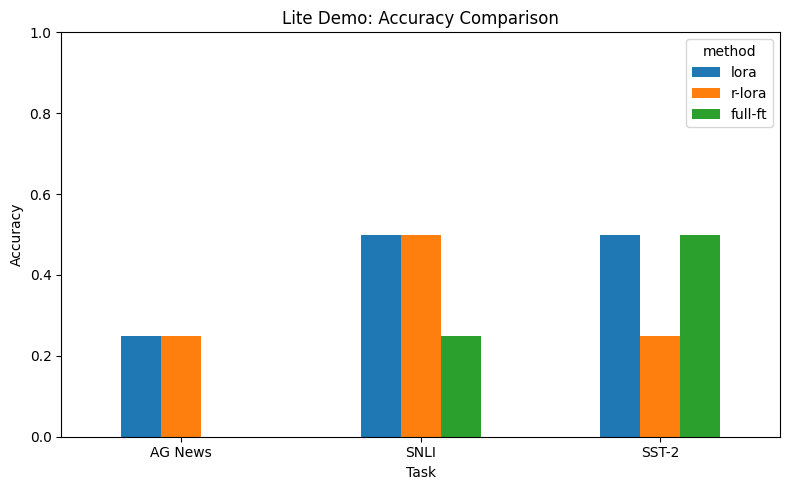

Saved files:
- multi_task_results_lite.csv
- summary_accuracy_lite.csv
- accuracy_comparison_lite.png


In [9]:

df_results.to_csv("multi_task_results_lite.csv", index=False)

summary = df_results.pivot(index="task", columns="method", values="eval_accuracy")
summary = summary[["lora", "r-lora", "full-ft"]]
summary.to_csv("summary_accuracy_lite.csv")

print("Summary accuracy:")
display(summary)

ax = summary.plot(kind="bar", figsize=(8, 5))
plt.title("Lite Demo: Accuracy Comparison")
plt.ylabel("Accuracy")
plt.xlabel("Task")
plt.ylim(0, 1)
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig("accuracy_comparison_lite.png", dpi=200)
plt.show()

print("Saved files:")
print("- multi_task_results_lite.csv")
print("- summary_accuracy_lite.csv")
print("- accuracy_comparison_lite.png")
